In [4]:
import numpy as np
import matplotlib.pyplot as plt
import miepython

In [ ]:

import urllib.request as u
Cu_data,_ = u.urlretrieve("https://refractiveindex.info/data_csv.php?datafile=database/data-nk/main/Al/Rakic.yml", "Cu_data.csv")
Au_data,_ = u.urlretrieve("https://refractiveindex.info/data_csv.php?datafile=database/data-nk/main/Na/Smith.yml", "Au_data.csv")
Ag_data,_ = u.urlretrieve("https://refractiveindex.info/data_csv.php?datafile=database/data-nk/main/Ag/Johnson.yml", "Ag_data.csv")


In [5]:
with open(Au_data) as AlData:
    AlData.readline()
    n = []
    k = []
    wavelength = []
    flag = 0
    for line in AlData:
        StrLine = line.rstrip()
        if flag == 0:
            if StrLine == "":
                flag = 1
                continue
            n.append(StrLine.split(",")[1])
            wavelength.append(StrLine.split(",")[0])
        elif flag == 1:
            flag = 2
            continue
        elif flag == 2:
            k.append(StrLine.split(",")[1])

realn = []
realk = []
realwl = []

realn = [float(i) for i in n]
print(len(realn))
realk = [float(i) for i in k]
realwl = [float(i) for i in wavelength]
cmplxRefractionIndex = []
for elem in list(zip(realn, realk)):
    cmplxRefractionIndex.append(complex(*elem))

23


23


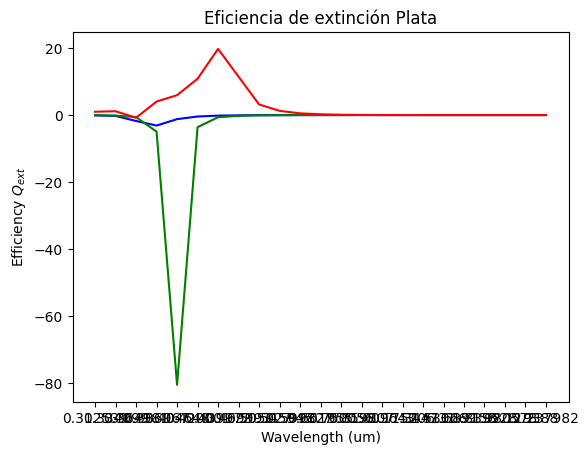

In [6]:
d = 90E-3
qext = [[],[],[],[],[],[],[],[],[]]
for i in range(1,10):
    d = i*10E-3
    kont= 0
    while kont < len(realwl):
        qext[i-1].append( miepython.ez_mie(cmplxRefractionIndex[kont], d, realwl[kont])[0])
        kont += 1

min = 0
max = len(qext[0])-0
print(len(qext[0]))
plt.plot(wavelength[min:max],qext[0][min:max],color='blue')
plt.plot(wavelength[min:max],qext[4][min:max],color='green')
plt.plot(wavelength[min:max],qext[8][min:max],color='red')
plt.xlabel("Wavelength (um)")
plt.ylabel("Efficiency $Q_{ext}$")
plt.title("Eficiencia de extinción Plata")
#plt.xlim(300,800)
#plt.ylim(1,2.5)
plt.show()